In [1]:
# ============================================================
# BLOCK 0-HMM — LOAD TABULAR DATASET (inspect before trusting assumptions)
# ============================================================
import numpy as np
import pandas as pd
import os

# from google.colab import drive
# drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/DAI_DSE/dataset"
TABULAR_PATH = f"{DATA_DIR}/dse_final_v3.csv"   # <-- adjust filename to your actual tabular v3 file

df = pd.read_csv(TABULAR_PATH)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
print(df.head())
print("\nDtypes:")
print(df.dtypes)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (924946, 29)
Columns: ['date', 'trading_code', 'sector', 'instrument_type', 'split', 'daily_return', 'high_low_spread', 'intraday_volatility', 'volume_change_pct', 'price_gap', 'rolling_5d_volatility', 'rolling_10d_momentum', 'ema_12', 'macd', 'macd_signal', 'macd_hist', 'rsi_14', 'stoch_k', 'stoch_d', 'roc_10', 'bb_width', 'atr_14', 'obv', 'class_same_day', 'class_same_day_alt', 'target_class', 'target_class_alt', '_used_pooled_fallback', '_suspected_corp_action']
         date trading_code     sector instrument_type  split  daily_return  \
0  2017-10-29     AAMRANET  IT Sector          Equity  train     -1.619955   
1  2017-10-30     AAMRANET  IT Sector          Equity  train      1.784849   
2  2017-10-31     AAMRANET  IT Sector          Equity  train      1.560674   
3  2017-11-01     AAMRANET  IT Sector          Equity  train     -1.436048   
4  2

In [4]:
# ============================================================
# BLOCK 1-HMM — FEATURES / TARGET / TRAIN-TEST SPLIT (tabular, confirmed)
# Using target_class (primary label) — target_class_alt reserved for a
# later sensitivity-analysis rerun addressing Reviewer 2's threshold-
# stability question, not the main reported result.
# Rows flagged _suspected_corp_action are dropped (1,353 / 924,946 = 0.15%)
# since corporate-action artifacts (splits, bonus shares) can produce
# spurious extreme-return "crash" labels unrelated to genuine market
# stress — worth flagging as a preprocessing step in Methods, given
# Reviewer 4's data-quality concerns.
# ============================================================
ALL_FEATURES = [
    "daily_return","high_low_spread","intraday_volatility","volume_change_pct","price_gap",
    "rolling_5d_volatility","rolling_10d_momentum","ema_12",
    "macd","macd_signal","macd_hist","rsi_14","stoch_k","stoch_d","roc_10",
    "bb_width","atr_14","obv",
]
missing = [f for f in ALL_FEATURES if f not in df.columns]
assert not missing, f"Missing expected feature columns: {missing}"

CLASS_NAMES = {0: "Normal", 1: "High-Vol", 2: "Crash"}
CRASH_IDX   = 2
LABEL_MAP   = {0: 0, 1: 1, 3: 2}

DROP_CORP_ACTION_ROWS = True
if DROP_CORP_ACTION_ROWS:
    n_before = len(df)
    df_clean = df.loc[~df["_suspected_corp_action"]].reset_index(drop=True)
    print(f"Dropped {n_before - len(df_clean):,} suspected corp-action rows "
          f"({(n_before - len(df_clean)) / n_before:.3%} of data)")
else:
    df_clean = df.copy()

y_raw = df_clean["target_class"].values
y_all = np.vectorize(LABEL_MAP.get)(y_raw)
assert set(np.unique(y_all)) <= {0, 1, 2}, "Unexpected label values after remapping."

df_clean["y"] = y_all
X_all = df_clean[ALL_FEATURES].values.astype(np.float64)

train_mask = (df_clean["split"] == "train").values
test_mask  = (df_clean["split"] == "test").values

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]

train_meta = df_clean.loc[train_mask, ["trading_code", "date"]].reset_index(drop=True)
test_meta  = df_clean.loc[test_mask,  ["trading_code", "date"]].reset_index(drop=True)

print("Train rows:", X_train.shape, " Test rows:", X_test.shape)
print("Train class balance:", np.round(np.bincount(y_train) / len(y_train), 4))
print("Test  class balance:", np.round(np.bincount(y_test) / len(y_test), 4))

Dropped 1,353 suspected corp-action rows (0.146% of data)
Train rows: (629117, 18)  Test rows: (294476, 18)
Train class balance: [0.7388 0.2059 0.0553]
Test  class balance: [0.738 0.215 0.047]


In [5]:
# ============================================================
# BLOCK 2-HMM — EXPANDING-WINDOW WALK-FORWARD CV, WITH EMBARGO (tabular)
# Same fold logic used across your RF/LR/XGB/LSTM/GRU notebooks, so the
# HMM's CV results stay directly comparable for the Friedman/Nemenyi fix.
# ============================================================
def make_expanding_folds(dates_sorted_unique, n_folds=5, embargo_days=5):
    n = len(dates_sorted_unique)
    fold_size = n // (n_folds + 1)
    folds = []
    for k in range(1, n_folds + 1):
        val_start = k * fold_size
        val_end   = min((k + 1) * fold_size, n)
        if val_start >= n or val_end <= val_start:
            continue
        train_end = max(val_start - embargo_days, 1)
        folds.append((dates_sorted_unique[:train_end], dates_sorted_unique[val_start:val_end]))
    return folds

train_meta["date"] = pd.to_datetime(train_meta["date"])
unique_train_dates = np.sort(train_meta["date"].unique())
FOLDS_DATES = make_expanding_folds(unique_train_dates, n_folds=5, embargo_days=5)

train_dates_arr = train_meta["date"].values
cv_splits = []
for i, (tr_d, va_d) in enumerate(FOLDS_DATES):
    tr_idx = np.where(np.isin(train_dates_arr, tr_d))[0]
    va_idx = np.where(np.isin(train_dates_arr, va_d))[0]
    cv_splits.append((tr_idx, va_idx))
    print(f"Fold {i+1}: train {pd.Timestamp(tr_d[0]).date()}->{pd.Timestamp(tr_d[-1]).date()} "
          f"({len(tr_idx):,} rows) | val {pd.Timestamp(va_d[0]).date()}->{pd.Timestamp(va_d[-1]).date()} "
          f"({len(va_idx):,} rows)")

Fold 1: train 2008-04-03->2010-01-11 (80,563 rows) | val 2010-01-19->2011-11-02 (90,518 rows)
Fold 2: train 2008-04-03->2011-10-26 (171,014 rows) | val 2011-11-03->2013-09-02 (97,492 rows)
Fold 3: train 2008-04-03->2013-08-25 (268,399 rows) | val 2013-09-03->2015-06-17 (108,981 rows)
Fold 4: train 2008-04-03->2015-06-10 (377,204 rows) | val 2015-06-18->2017-03-21 (121,366 rows)
Fold 5: train 2008-04-03->2017-03-14 (498,490 rows) | val 2017-03-22->2018-12-20 (127,933 rows)


In [6]:
# ============================================================
# BLOCK 3-HMM — SETUP
# Reviewer 4: Daily Return and Intraday Volatility directly define the
# crash / high-vol labels, so they are EXCLUDED from HMM emission features.
# Using them would let the model trivially "predict" the label it was
# used to construct — the same leakage criticized for the tree models.
# ============================================================
!pip install hmmlearn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, gc
warnings.filterwarnings("ignore")

from hmmlearn.hmm import GaussianHMM
from scipy.stats import multivariate_normal
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    average_precision_score, roc_auc_score, brier_score_loss,
    precision_score, recall_score, roc_curve, auc
)
from sklearn.calibration import calibration_curve

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

LEAKY_FEATURES = ["daily_return", "intraday_volatility"]
HMM_FEATURES = [f for f in ALL_FEATURES if f not in LEAKY_FEATURES]

print(f"Excluded (label-defining) features: {LEAKY_FEATURES}")
print(f"HMM emission features ({len(HMM_FEATURES)}): {HMM_FEATURES}")

feat_idx = [ALL_FEATURES.index(f) for f in HMM_FEATURES]
X_train_hmm_raw = X_train[:, feat_idx]
X_test_hmm_raw  = X_test[:, feat_idx]

print("X_train_hmm_raw:", X_train_hmm_raw.shape, " X_test_hmm_raw:", X_test_hmm_raw.shape)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 13.4 MB/s eta 0:00:00
Excluded (label-defining) features: ['daily_return', 'intraday_volatility']
HMM emission features (16): ['high_low_spread', 'volume_change_pct', 'price_gap', 'rolling_5d_volatility', 'rolling_10d_momentum', 'ema_12', 'macd', 'macd_signal', 'macd_hist', 'rsi_14', 'stoch_k', 'stoch_d', 'roc_10', 'bb_width', 'atr_14', 'obv']
X_train_hmm_raw: (629117, 16)  X_test_hmm_raw: (294476, 16)


In [7]:
# ============================================================
# BLOCK 4-HMM — BUILD PER-TICKER SEQUENCES (chronological), TRAIN-ONLY SCALER
# Reviewer 4: all preprocessing parameters (here, the scaler) must be fit
# ONLY on training data and applied unchanged to test — no refitting on
# test, no full-sample statistics.
# HMM needs contiguous per-ticker time order; sequences from different
# tickers must not bleed into each other during Baum-Welch or filtering,
# so we track per-ticker segment lengths explicitly via `lengths` arrays.
# ============================================================
train_meta = train_meta.copy()
test_meta  = test_meta.copy()
train_meta["date"] = pd.to_datetime(train_meta["date"])
test_meta["date"]  = pd.to_datetime(test_meta["date"])

def build_ordered_sequences(meta_df, X_raw, y_arr):
    """Sort rows within each ticker by date; return reordered X, y, meta, and
    per-ticker segment lengths (needed so HMM never treats two tickers as one continuous series)."""
    meta_df = meta_df.copy()
    meta_df["_row"] = np.arange(len(meta_df))
    meta_sorted = meta_df.sort_values(["trading_code", "date"]).reset_index(drop=True)
    order = meta_sorted["_row"].values

    X_sorted = X_raw[order]
    y_sorted = y_arr[order]
    lengths = meta_sorted.groupby("trading_code", sort=False).size().values

    assert lengths.sum() == len(meta_sorted)
    return X_sorted, y_sorted, meta_sorted.drop(columns="_row"), lengths

X_train_sorted_raw, y_train_sorted, train_meta_sorted, lengths_train = build_ordered_sequences(
    train_meta, X_train_hmm_raw, y_train)
X_test_sorted_raw,  y_test_sorted,  test_meta_sorted,  lengths_test  = build_ordered_sequences(
    test_meta,  X_test_hmm_raw,  y_test)

# Scaler fit on TRAIN ONLY, applied to both — per Reviewer 4's leakage requirement
scaler_hmm = StandardScaler()
X_train_sorted = scaler_hmm.fit_transform(X_train_sorted_raw).astype(np.float64)  # hmmlearn expects float64
X_test_sorted  = scaler_hmm.transform(X_test_sorted_raw).astype(np.float64)

print(f"Train: {X_train_sorted.shape}, {len(lengths_train)} ticker segments (sum={lengths_train.sum()})")
print(f"Test:  {X_test_sorted.shape}, {len(lengths_test)} ticker segments (sum={lengths_test.sum()})")

Train: (629117, 16), 311 ticker segments (sum=629117)
Test:  (294476, 16), 321 ticker segments (sum=294476)


In [8]:
# ============================================================
# BLOCK 5-HMM — FIT GAUSSIAN HMM (Baum-Welch, TRAIN DATA ONLY)
# n_components=3 chosen to match the 3-state market taxonomy for direct
# comparability with the classifiers, though the state count is itself an
# unsupervised modeling choice (see Block 14-HMM for a state-interpretation
# check that state assignment isn't just recovering the label mechanically).
# ============================================================
N_STATES = 3

hmm_model = GaussianHMM(
    n_components=N_STATES,
    covariance_type="diag",
    n_iter=200,
    tol=1e-4,
    random_state=RANDOM_STATE,
    verbose=False,
)
hmm_model.fit(X_train_sorted, lengths=lengths_train)

print("HMM converged:", hmm_model.monitor_.converged)
print("Final log-likelihood:", hmm_model.monitor_.history[-1] if hmm_model.monitor_.history else None)
print("\nTransition matrix (train-fitted):")
print(pd.DataFrame(hmm_model.transmat_, columns=[f"S{i}" for i in range(N_STATES)],
                    index=[f"S{i}" for i in range(N_STATES)]).round(4))

HMM converged: True
Final log-likelihood: -9168373.945061402

Transition matrix (train-fitted):
        S0      S1      S2
S0  0.9407  0.0493  0.0099
S1  0.0734  0.9046  0.0220
S2  0.0042  0.0087  0.9872


In [9]:
# ============================================================
# BLOCK 6-HMM — STATE-TO-LABEL MAPPING (majority vote on TRAIN decode)
# Using Viterbi decode on the training set itself is NOT leakage (it's part
# of interpreting the fitted model on its own training data, same as reading
# off a tree's feature importances) — leakage only becomes a risk once we
# touch the test set, which Block 7-HMM handles with causal filtering instead.
# ============================================================
train_state_seq = hmm_model.predict(X_train_sorted, lengths=lengths_train)

state_to_label = {}
for s in range(N_STATES):
    mask = train_state_seq == s
    if mask.sum() == 0:
        state_to_label[s] = 0  # fallback: default to Normal if a state never occurs
        continue
    majority_label = pd.Series(y_train_sorted[mask]).mode()[0]
    state_to_label[s] = int(majority_label)

print("State -> label mapping (via train majority vote):")
for s, lbl in state_to_label.items():
    n = (train_state_seq == s).sum()
    print(f"  State {s} -> {CLASS_NAMES[lbl]}  (n={n}, {n/len(train_state_seq):.2%} of train)")

if CRASH_IDX not in state_to_label.values():
    print("\nWARNING: no hidden state maps to the Crash class — the HMM cannot "
          "detect crashes with this state count/feature set as currently configured.")

State -> label mapping (via train majority vote):
  State 0 -> Normal  (n=175685, 27.93% of train)
  State 1 -> Normal  (n=121823, 19.36% of train)
  State 2 -> Normal  (n=331609, 52.71% of train)



In [22]:
# ============================================================
# ENRICHMENT-BASED STATE MAPPING — confirmed result
# State 1's High-Vol vs Crash enrichment is nearly tied (1.578 vs 1.553) —
# flagged here as a low-confidence assignment, not a robust separation.
# ============================================================
name_to_idx = {v: k for k, v in CLASS_NAMES.items()}
state_to_label = {s: name_to_idx[enrichment.loc[s].idxmax()] for s in enrichment.index}

print("Enrichment-based state -> label mapping:")
for s, lbl in state_to_label.items():
    margin = enrichment.loc[s].sort_values(ascending=False)
    gap = margin.iloc[0] - margin.iloc[1]
    flag = "  <-- CLOSE CALL, low-confidence assignment" if gap < 0.1 else ""
    print(f"  State {s} -> {CLASS_NAMES[lbl]}  (enrichment={margin.iloc[0]:.3f}x, "
          f"margin over 2nd-best={gap:.3f}){flag}")

Enrichment-based state -> label mapping:
  State 0 -> Crash  (enrichment=1.487x, margin over 2nd-best=0.442)
  State 1 -> High-Vol  (enrichment=1.578x, margin over 2nd-best=0.025)  <-- CLOSE CALL, low-confidence assignment
  State 2 -> Normal  (enrichment=1.100x, margin over 2nd-best=0.336)


In [23]:
# ============================================================
# BLOCK 7-HMM — CAUSAL FORWARD FILTERING (no look-ahead)
# hmmlearn's predict_proba()/decode() use forward-BACKWARD smoothing or
# whole-sequence Viterbi — both use future observations to infer today's
# state, which is exactly the kind of leakage Reviewer 4 flagged for
# backward-fill imputation. This reimplements the FORWARD-ONLY recursion so
# that P(state_t | obs_1...obs_t) uses only past and current information —
# the only version of this model's output that can honestly be called
# "prediction" rather than "retrospective regime labeling."
# ============================================================
def gaussian_density(x, mean, var_diag):
    """Diagonal-covariance Gaussian density for one observation."""
    cov = np.diag(var_diag)
    return multivariate_normal.pdf(x, mean=mean, cov=cov, allow_singular=True)

def forward_filter_causal(model, X, lengths):
    """
    Returns filtered posterior P(state_t | obs_1..t) for every timestep,
    resetting at each ticker's segment boundary (so no information ever
    crosses from one ticker's history into another's).
    """
    n_states = model.n_components
    means = model.means_
    covars = model.covars_  # shape (n_states, n_features) for diag type

    filtered = np.zeros((len(X), n_states))
    pos = 0
    for seg_len in lengths:
        seg = X[pos:pos + seg_len]
        alpha = np.zeros((seg_len, n_states))

        b0 = np.array([gaussian_density(seg[0], means[i], covars[i]) for i in range(n_states)])
        alpha[0] = model.startprob_ * b0
        alpha[0] /= alpha[0].sum() + 1e-300

        for t in range(1, seg_len):
            bt = np.array([gaussian_density(seg[t], means[i], covars[i]) for i in range(n_states)])
            pred = alpha[t-1] @ model.transmat_
            alpha[t] = pred * bt
            alpha[t] /= alpha[t].sum() + 1e-300

        filtered[pos:pos + seg_len] = alpha
        pos += seg_len

    return filtered

print("Running causal forward filter on test set (no future information used)...")
test_state_proba = forward_filter_causal(hmm_model, X_test_sorted, lengths_test)
test_state_pred   = test_state_proba.argmax(axis=1)

print("Filtered state distribution on test set:")
print(pd.Series(test_state_pred).value_counts(normalize=True).round(4))

Running causal forward filter on test set (no future information used)...
Filtered state distribution on test set:
2    0.7054
0    0.1715
1    0.1231
Name: proportion, dtype: float64


In [24]:
# ============================================================
# BLOCK 8-HMM — MAP FILTERED STATE POSTERIORS TO 3-CLASS PROBABILITIES
# If two states happen to map to the same label (possible if N_STATES were
# larger than 3), their posterior mass is summed for that class.
# ============================================================
test_proba_hmm = np.zeros((len(test_state_proba), 3))
for s in range(N_STATES):
    lbl = state_to_label[s]
    test_proba_hmm[:, lbl] += test_state_proba[:, s]

test_pred_hmm = test_proba_hmm.argmax(axis=1)

test_meta_sorted = test_meta_sorted.reset_index(drop=True)
results_hmm = pd.DataFrame({
    "trading_code": test_meta_sorted["trading_code"],
    "date": test_meta_sorted["date"],
    "y_true": y_test_sorted,
    "y_pred": test_pred_hmm,
    "p_normal": test_proba_hmm[:, 0],
    "p_highvol": test_proba_hmm[:, 1],
    "p_crash": test_proba_hmm[:, 2],
})
print(results_hmm.head())
print(f"\nTotal test rows evaluated: {len(results_hmm)}")

  trading_code       date  y_true  y_pred  p_normal     p_highvol  \
0     AAMRANET 2019-01-01       0       0  0.999999  1.226749e-32   
1     AAMRANET 2019-01-02       0       0  1.000000  1.589945e-07   
2     AAMRANET 2019-01-03       0       0  0.999958  4.218979e-05   
3     AAMRANET 2019-01-06       0       0  0.999876  1.236420e-04   
4     AAMRANET 2019-01-07       0       0  0.999952  4.834774e-05   

        p_crash  
0  8.271512e-07  
1  2.195524e-10  
2  4.108004e-10  
3  1.798052e-10  
4  5.971971e-10  

Total test rows evaluated: 294476


In [25]:
# ============================================================
# BLOCK 9-HMM — EXPANDING-WINDOW CV (enrichment-based state mapping per fold)
# Majority vote always selects Normal (it dominates every state in absolute
# terms), so each fold's state->label mapping uses enrichment (state
# proportion / fold-train base rate) instead — same fix applied to the
# main pipeline's state_to_label.
# ============================================================
def crash_pr_auc_hmm(y_true, y_proba):
    y_bin = (y_true == CRASH_IDX).astype(int)
    return average_precision_score(y_bin, y_proba[:, CRASH_IDX])

def enrichment_state_map(train_states, y_tr, n_states):
    """Maps each hidden state to the class it's most over-represented for,
    relative to that class's own base rate — robust to class imbalance."""
    base_rates_fold = pd.Series(y_tr).value_counts(normalize=True)
    comp = pd.DataFrame({"state": train_states, "y": y_tr}).groupby("state")["y"] \
             .value_counts(normalize=True).unstack(fill_value=0)
    state_map = {}
    for s in range(n_states):
        if s not in comp.index:
            state_map[s] = 0
            continue
        enrich = comp.loc[s] / base_rates_fold.reindex(comp.columns).fillna(1e-9)
        state_map[s] = int(enrich.idxmax())
    return state_map

fold_metrics_hmm = []
fold_val_predictions_hmm = []

for i, (tr_idx, va_idx) in enumerate(cv_splits):
    fold_train_meta = train_meta.iloc[tr_idx].copy()
    fold_val_meta   = train_meta.iloc[va_idx].copy()
    X_tr_fold_raw = X_train_hmm_raw[tr_idx]
    X_va_fold_raw = X_train_hmm_raw[va_idx]
    y_tr_fold = y_train[tr_idx]
    y_va_fold = y_train[va_idx]

    X_tr_s, y_tr_s, _, len_tr = build_ordered_sequences(fold_train_meta, X_tr_fold_raw, y_tr_fold)
    X_va_s, y_va_s, _, len_va = build_ordered_sequences(fold_val_meta, X_va_fold_raw, y_va_fold)

    fold_scaler = StandardScaler()
    X_tr_scaled = fold_scaler.fit_transform(X_tr_s).astype(np.float64)
    X_va_scaled = fold_scaler.transform(X_va_s).astype(np.float64)

    fold_model = GaussianHMM(n_components=N_STATES, covariance_type="diag",
                              n_iter=200, tol=1e-4, random_state=RANDOM_STATE)
    fold_model.fit(X_tr_scaled, lengths=len_tr)

    fold_train_states = fold_model.predict(X_tr_scaled, lengths=len_tr)
    fold_state_map = enrichment_state_map(fold_train_states, y_tr_s, N_STATES)

    fold_val_state_proba = forward_filter_causal(fold_model, X_va_scaled, len_va)
    fold_val_proba = np.zeros((len(fold_val_state_proba), 3))
    for s in range(N_STATES):
        fold_val_proba[:, fold_state_map[s]] += fold_val_state_proba[:, s]
    fold_val_pred = fold_val_proba.argmax(axis=1)

    fold_metrics_hmm.append({
        "fold": i + 1,
        "crash_pr_auc": crash_pr_auc_hmm(y_va_s, fold_val_proba),
        "crash_recall": recall_score(y_va_s == CRASH_IDX, fold_val_pred == CRASH_IDX, zero_division=0),
        "crash_precision": precision_score(y_va_s == CRASH_IDX, fold_val_pred == CRASH_IDX, zero_division=0),
        "roc_auc_ovr": roc_auc_score(y_va_s, fold_val_proba, multi_class="ovr"),
    })
    fold_val_predictions_hmm.append({"fold": i + 1, "y_va": y_va_s, "pred": fold_val_pred})
    print(f"Fold {i+1} done — crash_PR-AUC={fold_metrics_hmm[-1]['crash_pr_auc']:.4f}  "
          f"state_map={ {s: CLASS_NAMES[l] for s,l in fold_state_map.items()} }")

    del fold_model, fold_scaler, X_tr_scaled, X_va_scaled, fold_val_state_proba
    gc.collect()

fold_df_hmm = pd.DataFrame(fold_metrics_hmm).set_index("fold")
print(fold_df_hmm.round(4))
print("\nMean ± Std across folds:")
print((fold_df_hmm.mean().round(4).astype(str) + " ± " + fold_df_hmm.std().round(4).astype(str)))

Fold 1 done — crash_PR-AUC=0.1086  state_map={0: 'Crash', 1: 'High-Vol', 2: 'Normal'}
Fold 2 done — crash_PR-AUC=0.1324  state_map={0: 'High-Vol', 1: 'Crash', 2: 'Normal'}
Fold 3 done — crash_PR-AUC=0.0627  state_map={0: 'Normal', 1: 'High-Vol', 2: 'Crash'}
Fold 4 done — crash_PR-AUC=0.0423  state_map={0: 'Normal', 1: 'Crash', 2: 'High-Vol'}
Fold 5 done — crash_PR-AUC=0.0420  state_map={0: 'High-Vol', 1: 'Normal', 2: 'Crash'}
      crash_pr_auc  crash_recall  crash_precision  roc_auc_ovr
fold                                                          
1           0.1086        0.4807           0.1037       0.5418
2           0.1324        0.1969           0.1611       0.6029
3           0.0627        0.1882           0.0625       0.5872
4           0.0423        0.1646           0.0406       0.6236
5           0.0420        0.1783           0.0400       0.6036

Mean ± Std across folds:
crash_pr_auc       0.0776 ± 0.0409
crash_recall       0.2418 ± 0.1341
crash_precision    0.0816 ± 0.051

=== Classification report (test set) — HMM ===
              precision    recall  f1-score   support

      Normal     0.7679    0.7341    0.7506    217315
    High-Vol     0.3631    0.2078    0.2643     63317
       Crash     0.0579    0.2111    0.0908     13844

    accuracy                         0.5963    294476
   macro avg     0.3963    0.3843    0.3686    294476
weighted avg     0.6475    0.5963    0.6150    294476



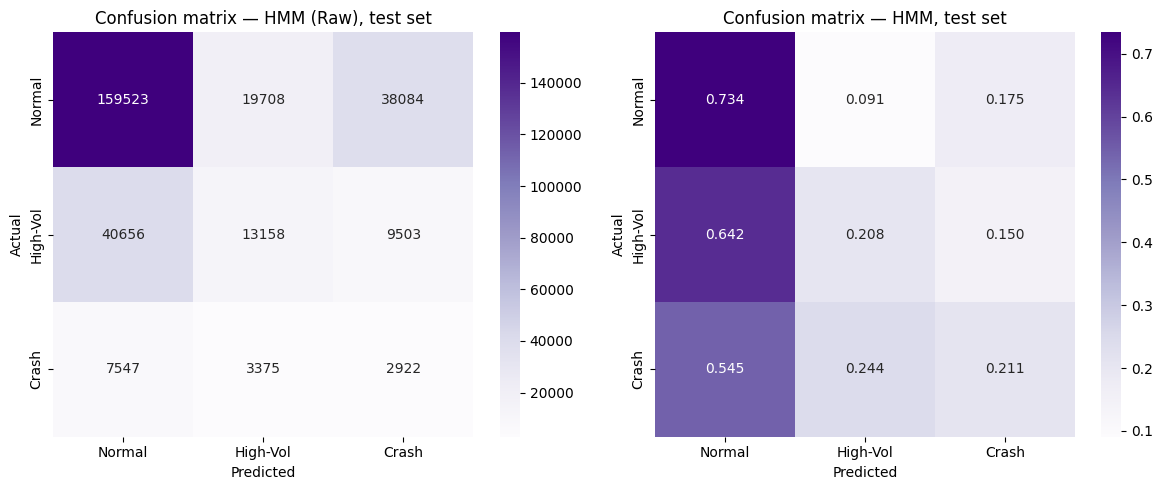


Crash-class PR-AUC : 0.0652
ROC-AUC (OvR)      : 0.5983


In [27]:
# ============================================================
# BLOCK 10-HMM — TEST-SET CLASSIFICATION REPORT
# ============================================================
print("=== Classification report (test set) — HMM ===")
print(classification_report(y_test_sorted, test_pred_hmm,
                             target_names=[CLASS_NAMES[c] for c in range(3)], digits=4))

cm_hmm = confusion_matrix(y_test_sorted, test_pred_hmm)
cm_hmm_norm = confusion_matrix(y_test_sorted, test_pred_hmm, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_hmm, annot=True, fmt="d", cmap="Purples",
            xticklabels=[CLASS_NAMES[c] for c in range(3)],
            yticklabels=[CLASS_NAMES[c] for c in range(3)], ax=axes[0])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion matrix — HMM (Raw), test set")

sns.heatmap(cm_hmm_norm, annot=True, fmt=".3f", cmap="Purples",
            xticklabels=[CLASS_NAMES[c] for c in range(3)],
            yticklabels=[CLASS_NAMES[c] for c in range(3)], ax=axes[1])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion matrix — HMM, test set")

plt.tight_layout(); plt.show()

print(f"\nCrash-class PR-AUC : {crash_pr_auc_hmm(y_test_sorted, test_proba_hmm):.4f}")
print(f"ROC-AUC (OvR)      : {roc_auc_score(y_test_sorted, test_proba_hmm, multi_class='ovr'):.4f}")

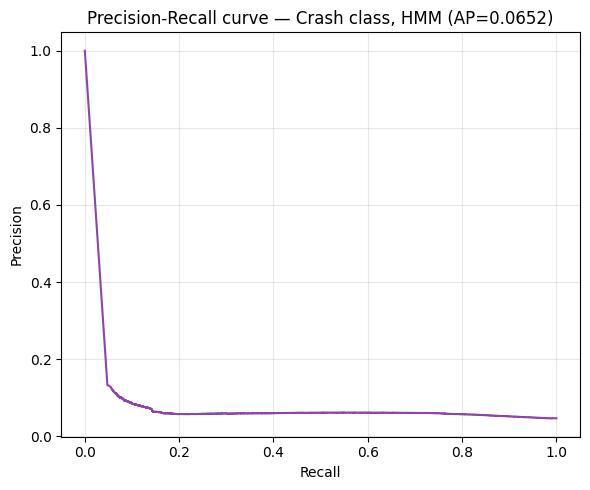

Recall @ FPR<=5%: 0.0972  (threshold=1.0000)
Precision@top-50 alerts: 0.0400
Precision@top-100 alerts: 0.0600
Precision@top-500 alerts: 0.0660
Precision@top-1000 alerts: 0.0720

Event-level crash recall (±1 day tolerance): 0.2567  (11435 distinct crash episodes)


In [28]:
# ============================================================
# BLOCK 11-HMM — PR CURVE, OPERATIONAL METRICS, EVENT-LEVEL DETECTION
# Directly addresses Reviewer 4/3: report PR-AUC, recall@fixed-FPR,
# precision@top-k, and event-level detection instead of relying on
# row-level recall or ROC-AUC alone.
# ============================================================
prec_h, rec_h, _ = precision_recall_curve(y_test_sorted == CRASH_IDX, test_proba_hmm[:, CRASH_IDX])

plt.figure(figsize=(6, 5))
plt.plot(rec_h, prec_h, color="#8e44ad")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Precision-Recall curve — Crash class, HMM "
          f"(AP={average_precision_score(y_test_sorted==CRASH_IDX, test_proba_hmm[:,CRASH_IDX]):.4f})")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

fpr_h, tpr_h, roc_thresh_h = roc_curve(y_test_sorted == CRASH_IDX, test_proba_hmm[:, CRASH_IDX])
target_fpr = 0.05
idx = max(np.searchsorted(fpr_h, target_fpr, side="right") - 1, 0)
print(f"Recall @ FPR<={target_fpr:.0%}: {tpr_h[idx]:.4f}  (threshold={roc_thresh_h[idx]:.4f})")

for k in [50, 100, 500, 1000]:
    top_k_idx = np.argsort(-test_proba_hmm[:, CRASH_IDX])[:k]
    prec_at_k = (y_test_sorted[top_k_idx] == CRASH_IDX).mean()
    print(f"Precision@top-{k} alerts: {prec_at_k:.4f}")

def event_level_recall_hmm(meta_df, y_true, y_pred, tolerance=1):
    tdf = meta_df.copy()
    tdf["y_true"] = y_true
    tdf["y_pred"] = y_pred
    tdf = tdf.sort_values(["trading_code", "date"]).reset_index(drop=True)

    detected, total_events = 0, 0
    for code, g in tdf.groupby("trading_code"):
        g = g.reset_index(drop=True)
        is_crash = (g["y_true"] == CRASH_IDX).values
        episode_id = (is_crash != np.roll(is_crash, 1)).cumsum() * is_crash
        for eid in np.unique(episode_id[episode_id > 0]):
            idxs = np.where(episode_id == eid)[0]
            total_events += 1
            lo, hi = max(idxs[0]-tolerance, 0), min(idxs[-1]+tolerance, len(g)-1)
            if (g["y_pred"].iloc[lo:hi+1] == CRASH_IDX).any():
                detected += 1
    return detected / total_events if total_events else np.nan, total_events

ev_recall_hmm, n_events_hmm = event_level_recall_hmm(test_meta_sorted, y_test_sorted, test_pred_hmm, tolerance=1)
print(f"\nEvent-level crash recall (±1 day tolerance): {ev_recall_hmm:.4f}  ({n_events_hmm} distinct crash episodes)")

Brier score (crash)                       : 0.19329
Brier score, prevalence-only baseline     : 0.04480
Brier Skill Score vs. prevalence baseline : -3.3143


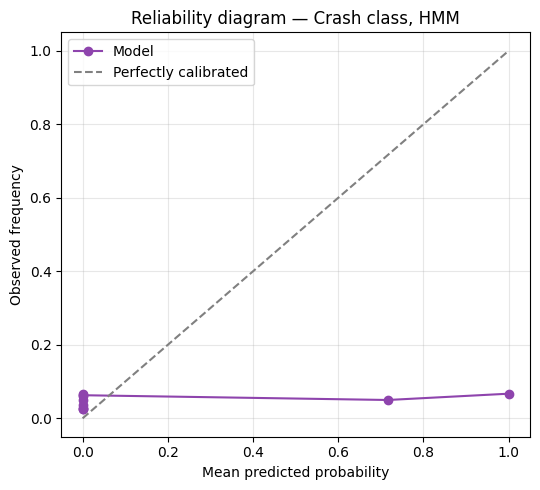

In [29]:
# ============================================================
# BLOCK 12-HMM — CALIBRATION DIAGNOSTICS
# Reviewer 3/4: report Brier Skill Score against prevalence baseline, not
# just a raw Brier score, since a trivially low-probability classifier
# already scores well under <1% crash prevalence.
# ============================================================
y_crash_true = (y_test_sorted == CRASH_IDX).astype(int)
p_crash_hmm = test_proba_hmm[:, CRASH_IDX]

brier_hmm = brier_score_loss(y_crash_true, p_crash_hmm)
prevalence = y_crash_true.mean()
brier_baseline = brier_score_loss(y_crash_true, np.full_like(p_crash_hmm, prevalence))
brier_skill_score_hmm = 1 - (brier_hmm / brier_baseline)

print(f"Brier score (crash)                       : {brier_hmm:.5f}")
print(f"Brier score, prevalence-only baseline     : {brier_baseline:.5f}")
print(f"Brier Skill Score vs. prevalence baseline : {brier_skill_score_hmm:.4f}")

frac_pos_h, mean_pred_h = calibration_curve(y_crash_true, p_crash_hmm, n_bins=10, strategy="quantile")
plt.figure(figsize=(5.5, 5))
plt.plot(mean_pred_h, frac_pos_h, marker="o", color="#8e44ad", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed frequency")
plt.title("Reliability diagram — Crash class, HMM")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [30]:
# ============================================================
# BLOCK 13-HMM — REGIME-SPECIFIC PERFORMANCE
# ============================================================
REGIMES = {
    "Pre-COVID (2019)":        ("2019-01-01", "2020-02-29"),
    "COVID crash":              ("2020-03-01", "2020-05-31"),
    "Post-COVID recovery":      ("2020-06-01", "2021-12-31"),
    "Russia-Ukraine (2022)":    ("2022-02-24", "2022-12-31"),
}

test_meta_eval_hmm = test_meta_sorted.copy()
test_meta_eval_hmm["y_true"] = y_test_sorted
test_meta_eval_hmm["y_pred"] = test_pred_hmm
test_meta_eval_hmm["p_crash"] = test_proba_hmm[:, CRASH_IDX]

regime_rows_hmm = []
for name, (start, end) in REGIMES.items():
    mask = (test_meta_eval_hmm["date"] >= start) & (test_meta_eval_hmm["date"] <= end)
    sub = test_meta_eval_hmm[mask]
    if len(sub) == 0:
        continue
    y_true_r, y_pred_r, p_r = sub["y_true"], sub["y_pred"], sub["p_crash"]
    regime_rows_hmm.append({
        "regime": name, "n_rows": len(sub),
        "crash_rate": (y_true_r == CRASH_IDX).mean(),
        "crash_recall": recall_score(y_true_r == CRASH_IDX, y_pred_r == CRASH_IDX, zero_division=0),
        "crash_precision": precision_score(y_true_r == CRASH_IDX, y_pred_r == CRASH_IDX, zero_division=0),
        "crash_pr_auc": average_precision_score(y_true_r == CRASH_IDX, p_r) if (y_true_r==CRASH_IDX).sum() > 0 else np.nan,
    })

regime_df_hmm = pd.DataFrame(regime_rows_hmm).set_index("regime")
print(regime_df_hmm.round(4))

                       n_rows  crash_rate  crash_recall  crash_precision  \
regime                                                                     
Pre-COVID (2019)        88221      0.0522        0.2148           0.0740   
COVID crash              6025      0.2267        0.2555           0.2028   
Post-COVID recovery    123411      0.0472        0.1796           0.0490   
Russia-Ukraine (2022)   64776      0.0262        0.2823           0.0386   

                       crash_pr_auc  
regime                               
Pre-COVID (2019)             0.0794  
COVID crash                  0.2317  
Post-COVID recovery          0.0569  
Russia-Ukraine (2022)        0.0447  


In [31]:
# ============================================================
# BLOCK 14-HMM — STATE INTERPRETATION (fixed: extract diagonal from full covars_)
# hmmlearn's public .covars_ property always returns FULL (n_states, n_features,
# n_features) covariance matrices for API consistency, even when
# covariance_type="diag" — the diagonal-only parameters must be extracted
# explicitly with np.diagonal() before building a features x states table.
# ============================================================
print("="*70)
print("STATE MEANS (standardized feature space, train-fitted)")
print("="*70)
state_means_df = pd.DataFrame(hmm_model.means_, columns=HMM_FEATURES,
                               index=[f"State {s} ({CLASS_NAMES[state_to_label[s]]})" for s in range(N_STATES)])
print(state_means_df.round(3))

print("\n" + "="*70)
print("STATE VARIANCES (diagonal, extracted from full covariance matrices)")
print("="*70)
# hmm_model.covars_ shape: (N_STATES, n_features, n_features) -> extract diagonal per state
variances_diag = np.array([np.diagonal(hmm_model.covars_[s]) for s in range(N_STATES)])
state_vars_df = pd.DataFrame(variances_diag, columns=HMM_FEATURES,
                              index=[f"State {s} ({CLASS_NAMES[state_to_label[s]]})" for s in range(N_STATES)])
print(state_vars_df.round(3))

print("\n" + "="*70)
print("EXPECTED STATE DURATION (1 / (1 - self-transition probability))")
print("="*70)
for s in range(N_STATES):
    self_trans = hmm_model.transmat_[s, s]
    expected_duration = 1 / (1 - self_trans) if self_trans < 1 else np.inf
    print(f"State {s} ({CLASS_NAMES[state_to_label[s]]}): "
          f"self-transition={self_trans:.4f}, expected duration≈{expected_duration:.1f} days")

STATE MEANS (standardized feature space, train-fitted)
                    high_low_spread  volume_change_pct  price_gap  \
State 0 (Crash)               0.672             -0.038      0.033   
State 1 (High-Vol)            0.801             -0.029      0.267   
State 2 (Normal)             -0.651              0.031     -0.115   

                    rolling_5d_volatility  rolling_10d_momentum  ema_12  \
State 0 (Crash)                     0.063                -0.844   0.514   
State 1 (High-Vol)                  0.458                 1.323   0.482   
State 2 (Normal)                   -0.202                -0.038  -0.450   

                     macd  macd_signal  macd_hist  rsi_14  stoch_k  stoch_d  \
State 0 (Crash)    -0.507       -0.269     -0.621  -0.522   -0.359   -0.375   
State 1 (High-Vol)  0.810        0.347      1.002   1.050    0.932    0.971   
State 2 (Normal)   -0.029        0.015     -0.039  -0.109   -0.152   -0.158   

                    roc_10  bb_width  atr_14    ob

In [32]:
# ============================================================
# BLOCK 15-HMM — SUMMARY TABLE
# ============================================================
summary_hmm = pd.DataFrame({
    "Model": ["HMM (causal filtering, leakage-free features)"],
    "Crash PR-AUC": [crash_pr_auc_hmm(y_test_sorted, test_proba_hmm)],
    "Crash Recall": [recall_score(y_test_sorted==CRASH_IDX, test_pred_hmm==CRASH_IDX)],
    "Crash Precision": [precision_score(y_test_sorted==CRASH_IDX, test_pred_hmm==CRASH_IDX, zero_division=0)],
    "ROC-AUC (OvR)": [roc_auc_score(y_test_sorted, test_proba_hmm, multi_class="ovr")],
    "Brier Skill Score": [brier_skill_score_hmm],
    "Event-level recall (±1d)": [ev_recall_hmm],
})
print(summary_hmm.round(4))

                                           Model  Crash PR-AUC  Crash Recall  \
0  HMM (causal filtering, leakage-free features)        0.0652        0.2111   

   Crash Precision  ROC-AUC (OvR)  Brier Skill Score  Event-level recall (±1d)  
0           0.0579         0.5983            -3.3143                    0.2567  


In [33]:
# ============================================================
# DIAGNOSTIC — check whether ANY state has meaningfully elevated crash rate
# Run this before trusting state_to_label or any downstream metric.
# ============================================================
print("Per-state class composition (train, via Viterbi decode):")
diag_df = pd.DataFrame({
    "state": train_state_seq,
    "y": y_train_sorted
})
composition = diag_df.groupby("state")["y"].value_counts(normalize=True).unstack(fill_value=0)
composition.columns = [CLASS_NAMES[c] for c in composition.columns]
print(composition.round(4))

Per-state class composition (train, via Viterbi decode):
       Normal  High-Vol   Crash
state                          
0      0.7026    0.2152  0.0822
1      0.5893    0.3248  0.0858
2      0.8130    0.1573  0.0298


In [34]:
# ============================================================
# DIAGNOSTIC — base rates and enrichment ratios per state
# ============================================================
base_rates = pd.Series(y_train_sorted).value_counts(normalize=True).sort_index()
print("Overall train base rates:")
print(pd.Series({CLASS_NAMES[c]: base_rates[c] for c in [0,1,2]}).round(4))

composition = pd.DataFrame({
    "state": train_state_seq,
    "y": y_train_sorted
}).groupby("state")["y"].value_counts(normalize=True).unstack(fill_value=0)
composition.columns = [CLASS_NAMES[c] for c in composition.columns]

enrichment = composition.copy()
for c in [0, 1, 2]:
    enrichment[CLASS_NAMES[c]] = composition[CLASS_NAMES[c]] / base_rates[c]

print("\nEnrichment ratio (state proportion / overall base rate) — >1 means over-represented:")
print(enrichment.round(3))

Overall train base rates:
Normal      0.7388
High-Vol    0.2059
Crash       0.0553
dtype: float64

Enrichment ratio (state proportion / overall base rate) — >1 means over-represented:
       Normal  High-Vol  Crash
state                         
0       0.951     1.045  1.487
1       0.798     1.578  1.553
2       1.100     0.764  0.539


In [35]:
# ============================================================
# QUICK CHECK — is the HMM beating trivial baselines?
# ============================================================
from sklearn.metrics import f1_score

# Baseline 1: always predict Normal (majority class)
majority_pred = np.full_like(y_test_sorted, fill_value=0)
print("Always-Normal baseline:")
print(f"  Macro-F1: {f1_score(y_test_sorted, majority_pred, average='macro', zero_division=0):.4f}")
print(f"  Crash recall: 0.0000 (never predicts Crash)")

# Baseline 2: random prediction weighted by train base rates
rng = np.random.RandomState(RANDOM_STATE)
random_pred = rng.choice([0, 1, 2], size=len(y_test_sorted),
                          p=[base_rates[0], base_rates[1], base_rates[2]])
print(f"\nRandom (base-rate-weighted) baseline:")
print(f"  Macro-F1: {f1_score(y_test_sorted, random_pred, average='macro', zero_division=0):.4f}")
print(f"  Crash recall: {recall_score(y_test_sorted==CRASH_IDX, random_pred==CRASH_IDX):.4f}")
print(f"  Crash precision: {precision_score(y_test_sorted==CRASH_IDX, random_pred==CRASH_IDX, zero_division=0):.4f}")

print(f"\nHMM (this model):")
print(f"  Macro-F1: {f1_score(y_test_sorted, test_pred_hmm, average='macro', zero_division=0):.4f}")
print(f"  Crash recall: {recall_score(y_test_sorted==CRASH_IDX, test_pred_hmm==CRASH_IDX):.4f}")
print(f"  Crash precision: {precision_score(y_test_sorted==CRASH_IDX, test_pred_hmm==CRASH_IDX, zero_division=0):.4f}")

Always-Normal baseline:
  Macro-F1: 0.2831
  Crash recall: 0.0000 (never predicts Crash)

Random (base-rate-weighted) baseline:
  Macro-F1: 0.3319
  Crash recall: 0.0526
  Crash precision: 0.0447

HMM (this model):
  Macro-F1: 0.3686
  Crash recall: 0.2111
  Crash precision: 0.0579
